# 01 — Exploratory analysis of the processed trip dataset

Looks for structure in `cache/trips_meta.parquet` + `cache/sequences.npz`
that informs the modeling steps: when and where delays happen, what
correlates with them, how the degraded telemetry days look, and whether the
raw features carry usable signal.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import netmob_prep as prep

sns.set_theme(style="whitegrid", palette=["#1D9E75", "#FF6B6B", "#2196F3",
                                          "#FF9800", "#9C27B0", "#607D8B"])
OUT = "./cache"
meta = pd.read_parquet("./cache/trips_meta.parquet")
z = np.load("./cache/sequences.npz", allow_pickle=True)
X, lengths, y = z["X"], z["lengths"], z["y"]
meta["start_hour"] = pd.to_datetime(meta["start_time"]).dt.hour
meta["weekday"] = pd.to_datetime(meta["service_date"]).dt.dayofweek
print(f"{len(meta):,} trip instances | {meta.line_id.nunique()} lines | "
      f"{meta.service_date.nunique()} service days | delayed {meta.delayed.mean():.1%}")
meta.head(3)

22,605 trip instances | 50 lines | 20 service days | delayed 20.9%


,trip_instance_id,file_date,service_date,trip_id,vehicle,line_id,direction,gtfs_direction,snapshot,start_time,...,final_stop_delay_sec,start_deviation_sec,shape_len_m,progress_span_m,degraded_day,delayed,seq_len,headway_min,start_hour,weekday
0,2026-03-11_1103013_U_1,2026-03-11,2026-03-11,1103013_U_1,69178,57,0,0,TransOceanico_20260315,2026-03-11 05:58:57,...,-1232.348472,117.0,7571.3138,7102.978505,0,0,30,60.000000,5,2
1,2026-03-11_1103013_U_10,2026-03-11,2026-03-11,1103013_U_10,69178,57,0,0,TransOceanico_20260315,2026-03-11 11:53:32,...,-1726.138130,92.0,7571.3138,7262.280894,0,0,42,56.816667,11,2
2,2026-03-11_1103013_U_13,2026-03-11,2026-03-11,1103013_U_13,69178,57,0,0,TransOceanico_20260315,2026-03-11 13:56:53,...,-44.406866,53.0,7571.3138,6994.072432,0,0,43,60.000000,13,2


## 1. When are trips delayed? (hour × weekday)

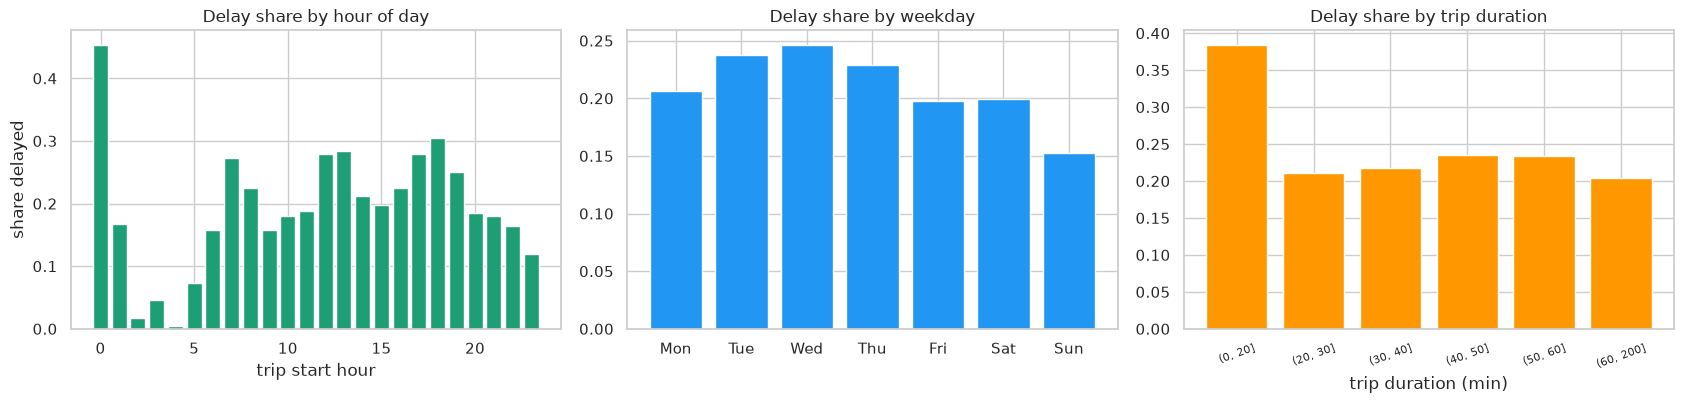

peak delay hours: {0: 0.45, 18: 0.31, 13: 0.28, 17: 0.28}


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
by_hour = meta.groupby("start_hour")["delayed"].agg(["mean", "size"])
axes[0].bar(by_hour.index, by_hour["mean"], color="#1D9E75")
axes[0].set_xlabel("trip start hour"); axes[0].set_ylabel("share delayed")
axes[0].set_title("Delay share by hour of day")

wd = meta.groupby("weekday")["delayed"].mean()
axes[1].bar(wd.index, wd.values, color="#2196F3")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_title("Delay share by weekday")

dur = meta.groupby(pd.cut(meta["duration_sec"] / 60, bins=[0, 20, 30, 40, 50, 60, 200]),
                   observed=True)["delayed"].mean()
axes[2].bar(range(len(dur)), dur.values, color="#FF9800")
axes[2].set_xticks(range(len(dur)))
axes[2].set_xticklabels([str(c) for c in dur.index], rotation=20, fontsize=8)
axes[2].set_xlabel("trip duration (min)"); axes[2].set_title("Delay share by trip duration")
plt.tight_layout(); plt.savefig(f"{OUT}/eda_when.png", dpi=120); plt.show()
print("peak delay hours:", by_hour["mean"].nlargest(4).round(2).to_dict())

## 2. Which lines are delayed? (top lines by volume)

            n  delayed  med_delay_min
line_id                              
55A       217     0.49           4.49
31        828     0.46           4.46
62        756     0.44           3.91
38A       211     0.42           2.37
49.1      211     0.40           2.77
46        351     0.36           0.77
OC2       531     0.31           1.43
26A       265     0.30           2.19
26        394     0.29          -0.29
21        376     0.28           2.82
24        346     0.27           1.22
49.2     1547     0.27           1.71
39A       882     0.26          -0.60
48        480     0.24          -0.61
22        320     0.23           1.91


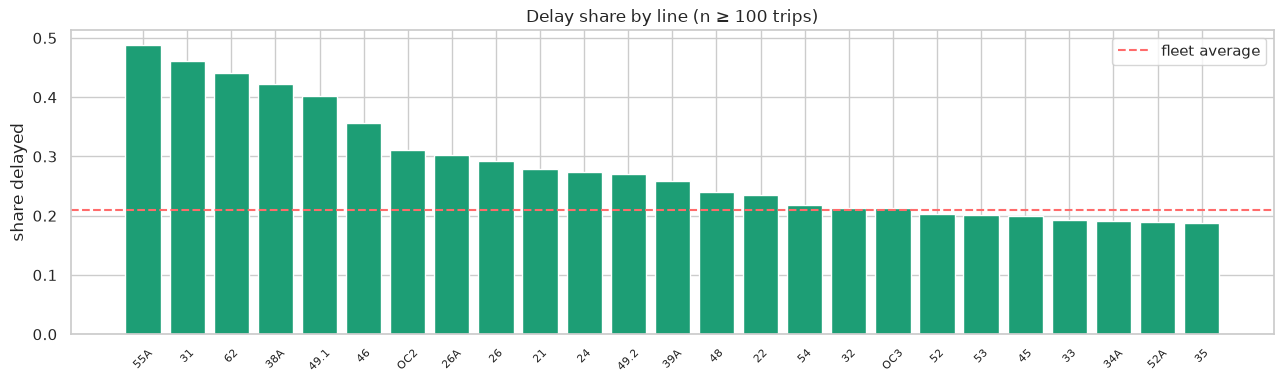

In [3]:
top = meta.groupby("line_id").agg(n=("delayed", "size"), delayed=("delayed", "mean"),
                                  med_delay_min=("median_delay_sec", lambda s: s.median() / 60))
top = top[top["n"] >= 100].sort_values("delayed", ascending=False)
print(top.head(15).round(2).to_string())
fig, ax = plt.subplots(figsize=(13, 4))
show = top.head(25)
ax.bar(range(len(show)), show["delayed"], color="#1D9E75")
ax.set_xticks(range(len(show))); ax.set_xticklabels(show.index, rotation=45, fontsize=8)
ax.axhline(meta["delayed"].mean(), color="#FF6B6B", ls="--", label="fleet average")
ax.set_ylabel("share delayed"); ax.set_title("Delay share by line (n ≥ 100 trips)")
ax.legend(); plt.tight_layout(); plt.savefig(f"{OUT}/eda_lines.png", dpi=120); plt.show()

## 3. Rain vs delays and ridership-relevant behaviour

       delayed  median_delay_sec
rainy                           
False    0.204           -93.017
True     0.273          -294.330
point-biserial rain↔median delay: r=-0.045, p=1.26e-11


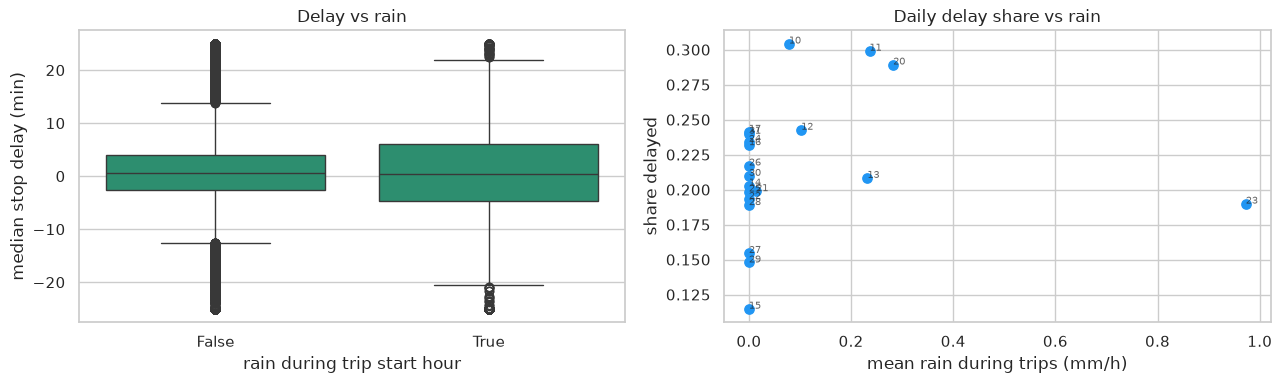

In [4]:
rain_utc = prep.load_rain_by_utc_hour()
# rain during each trip's window (local -> UTC = +3h)
starts = (pd.to_datetime(meta["start_time"]) + pd.Timedelta(hours=3)).dt.floor("h")
meta["rain_mm_trip"] = rain_utc.reindex(starts).fillna(0.0).to_numpy()
meta["rainy"] = meta["rain_mm_trip"] > 0

print(meta.groupby("rainy")[["delayed", "median_delay_sec"]].mean().round(3))
from scipy import stats
r, p = stats.pointbiserialr(meta["rainy"].astype(int), meta["median_delay_sec"])
print(f"point-biserial rain↔median delay: r={r:.3f}, p={p:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=meta, x="rainy", y=meta["median_delay_sec"].clip(-1500, 1500) / 60, ax=axes[0])
axes[0].set_xlabel("rain during trip start hour"); axes[0].set_ylabel("median stop delay (min)")
axes[0].set_title("Delay vs rain")
daily = meta.groupby("service_date").agg(delayed=("delayed", "mean"),
                                         rain=("rain_mm_trip", "mean"))
axes[1].scatter(daily["rain"], daily["delayed"], color="#2196F3", s=45)
for d, row in daily.iterrows():
    axes[1].annotate(d[8:], (row["rain"], row["delayed"]), fontsize=7, alpha=0.7)
axes[1].set_xlabel("mean rain during trips (mm/h)"); axes[1].set_ylabel("share delayed")
axes[1].set_title("Daily delay share vs rain")
plt.tight_layout(); plt.savefig(f"{OUT}/eda_rain.png", dpi=120); plt.show()

## 4. Degraded telemetry days (Mar 20 / 22 / 28)

               n  delayed  pts_per_trip  coverage  degraded
file_date                                                  
2026-03-11  1454     0.30        360.33      0.88         0
2026-03-12  1419     0.24        362.49      0.89         0
2026-03-13  1584     0.21        375.38      0.91         0
2026-03-14  1401     0.20        338.26      0.91         0
2026-03-15  1021     0.12        326.38      0.92         0
2026-03-16   816     0.23        342.91      0.90         0
2026-03-17   319     0.24        337.80      0.91         0
2026-03-20   612     0.29        308.02      0.87         1
2026-03-21  1233     0.20        275.61      0.90         0
2026-03-22  1045     0.19         42.95      0.84         1
2026-03-23  1405     0.19        294.10      0.86         0
2026-03-24  1606     0.23        352.62      0.89         0
2026-03-25  1588     0.20        355.82      0.91         0
2026-03-26  1579     0.22        367.30      0.91         0
2026-03-27  1733     0.15        370.82 

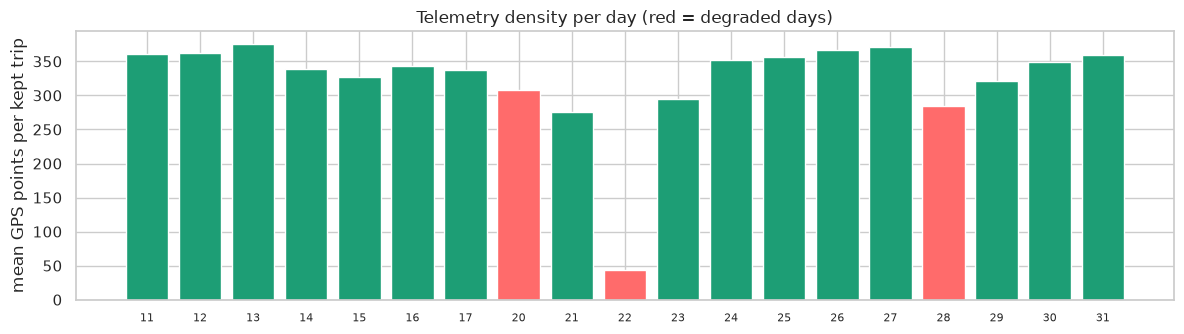

In [5]:
per_day = meta.groupby("file_date").agg(
    n=("delayed", "size"), delayed=("delayed", "mean"),
    pts_per_trip=("n_points", "mean"), coverage=("stop_coverage", "mean"),
    degraded=("degraded_day", "max"))
print(per_day.round(2).to_string())
fig, ax = plt.subplots(figsize=(12, 3.5))
colors = ["#FF6B6B" if d else "#1D9E75" for d in per_day["degraded"]]
ax.bar(range(len(per_day)), per_day["pts_per_trip"], color=colors)
ax.set_xticks(range(len(per_day)))
ax.set_xticklabels([s[8:] for s in per_day.index], fontsize=8)
ax.set_ylabel("mean GPS points per kept trip")
ax.set_title("Telemetry density per day (red = degraded days)")
plt.tight_layout(); plt.savefig(f"{OUT}/eda_degraded.png", dpi=120); plt.show()

## 5. Do the sequence features separate the classes at all?

Per-trip means of each feature, compared between delayed and on-time trips —
a first hint of whether the AE has signal to compress.

                on_time_mean  delayed_mean  std_gap
progress_frac          0.685         0.548    0.947
dwell_frac             0.763         0.725    0.290
cross_track_m         16.587        13.104    0.262
tod_sin               -0.034        -0.192    0.209
heading_change         7.983         7.533    0.206
accel                 -0.113        -0.053    0.191
headway_min           27.321        30.957    0.184
speed_mps              2.912         3.100    0.139
progress_rate          0.016         0.015    0.132
is_weekend             0.285         0.230    0.124
tod_cos               -0.298        -0.325    0.048
rain_mm                0.110         0.113    0.004


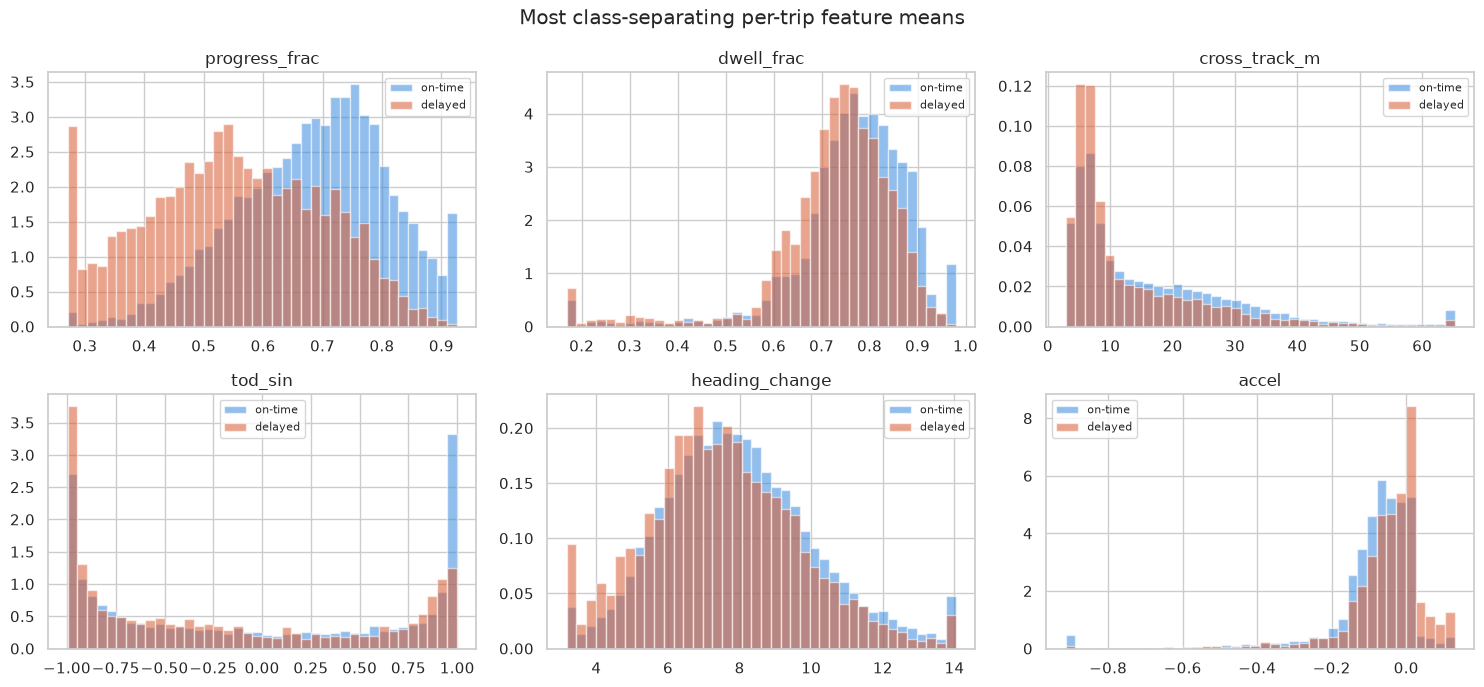

In [6]:
mask = (np.arange(X.shape[1])[None, :] < lengths[:, None])[:, :, None]
feat_mean = (X * mask).sum(1) / np.maximum(mask.sum(1), 1)
fm = pd.DataFrame(feat_mean, columns=prep.FEATURE_COLS)
fm["delayed"] = y
diff = (fm.groupby("delayed").mean().T
        .assign(abs_gap=lambda d: (d[1] - d[0]).abs() /
                fm[prep.FEATURE_COLS].std())).sort_values("abs_gap", ascending=False)
diff.columns = ["on_time_mean", "delayed_mean", "std_gap"]
print(diff.round(3).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, diff.index[:6]):
    for lab, color, name in [(0, "#378ADD", "on-time"), (1, "#D85A30", "delayed")]:
        vals = fm.loc[fm["delayed"] == lab, col]
        lo, hi = fm[col].quantile([0.01, 0.99])
        ax.hist(vals.clip(lo, hi), bins=40, alpha=0.55, density=True,
                color=color, label=name)
    ax.set_title(col); ax.legend(fontsize=8)
fig.suptitle("Most class-separating per-trip feature means")
plt.tight_layout(); plt.savefig(f"{OUT}/eda_features.png", dpi=120); plt.show()

## 6. Feature correlation & data-quality notes

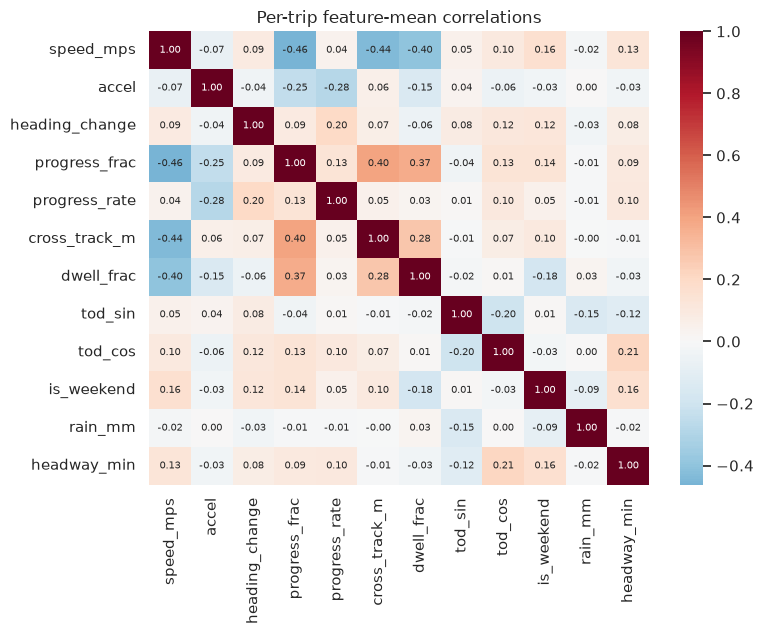

speed > 30 m/s bins: 4786 (0.3308% of bins) — GPS-jump artifacts, left in on purpose: they are exactly what the anomaly stage should flag


In [7]:
corr = fm[prep.FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Per-trip feature-mean correlations")
plt.tight_layout(); plt.savefig(f"{OUT}/eda_corr.png", dpi=120); plt.show()

spd = X[:, :, prep.FEATURE_COLS.index("speed_mps")]
print(f"speed > 30 m/s bins: {(spd > 30).sum()} "
      f"({(spd > 30).mean():.4%} of bins) — GPS-jump artifacts, "
      "left in on purpose: they are exactly what the anomaly stage should flag")

## 7. Takeaways

* **Delays are strongly time-structured** — late-afternoon peak-hour trips are
  delayed far more often than dawn trips, and weekdays more than Sundays, so
  `tod_sin/cos` + `is_weekend` carry real signal.
* **Line identity matters** — several high-volume lines are delayed at 2–3×
  the fleet average; the AE sees this only through dynamics (speed/dwell
  profiles), which is the harder, more interesting test.
* **Rain raises the odds of a trip being delayed** (delayed share ≈ 27%
  on rainy trip-hours vs ≈ 20% dry), even though the *continuous*
  point-biserial correlation is slightly negative — rain fattens the late
  tail while shifting the bulk of trips earlier (lighter traffic /
  skipped stops). The weather channel and the rain-vs-anomaly analysis
  planned in 03 remain justified.
* **Degraded days are visible** in points-per-trip density — a built-in
  ground truth for the reconstruction-error anomaly detector.
* **Speed/dwell/progress-rate distributions differ between classes**, so an
  unsupervised encoder has class-relevant structure to compress.